## **Using Natural Language Processing to investigate natural hazards in the Global South**

**Authors:** Taís M. Nunes Carvalho (carvalho@informatik.uni-leipzig.de) and Mariana Madruga de Brito (mariana.brito@ufz.de)

In this notebook, we provide an overview of text mining/natural language processing techniques using a sample from the dataset we will work with during the Training School.

The dataset is comprised of reports on immediate aid, recovery, and resilience-building in the aftermath of disasters led by the International Federation of Red Cross and Red Crescent Societies (IFRC). The sample dataset we will work on here focuses on reports on droughts.

The goals of this notebook are:
- Introduce basic tasks and methods of text analysis
- Present the dataset of IFRC reports
- Show some of the tasks we expect you to perform during the Training School

In [1]:
#from google.colab import drive
#drive.mount('/content/drive')

ModuleNotFoundError: No module named 'google'

### Install necessary packages

In [2]:
!pip install spacy
!python -m spacy download en_core_web_sm
!pip install sentence-transformers scikit-learn pandas

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 2.9 MB/s eta 0:00:00a 0:00:01
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Using cached murmurhash-1.0.10-cp39-cp39-macosx_11_0_arm64.whl.metadata (2.0 kB)
  Using cached cymem-2.0.8-cp39-cp39-macosx_11_0_arm64.whl.metadata (8.4 kB)
  Using cached preshed-3.0.9-cp39-cp39-macosx_11_0_arm64.whl.metadata (2.2 kB)
  Using cached thinc-8.2.5-cp39-cp39-macosx_11_0_arm64.whl.metadata (15 kB)
  Using cached wasabi-1.1.3-py3-none-any.whl.metadata (28 kB)
  Using cached srsly-2.4.8-cp39-cp39-macosx_11_0_arm64.whl.metadata (20 kB)
  Using cached catalogue-2.0.10-py3-none-any.whl.metadata (14 kB)
  Using cached pydantic-2.9.2-py3-none-any.whl.metadata (149 kB)
  Using cached annotated_types-0.7.0-py3-none-any.whl.metadata (15 kB)
  Using cached pydantic_core-2.23.4-cp39-cp39-macosx_11_0_arm64.whl.metadata (6.6 kB)
  Using cached blis-0.7.11-cp39-cp39-

### Load the required libraries

In [2]:
import pandas as pd
import requests
from matplotlib import pyplot as plt
import seaborn as sns
import re
import nltk
from nltk.tokenize import sent_tokenize
import spacy
from spacy import displacy
import matplotlib.pyplot as plt
from collections import Counter
from sentence_transformers import SentenceTransformer
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.manifold import TSNE
from nltk.corpus import stopwords

/Users/lseverino/miniforge3/envs/como_proj4/lib/python3.9/site-packages/sentence_transformers/cross_encoder/CrossEncoder.py:13: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from tqdm.autonotebook import tqdm, trange


### Data Exploration

The data is formatted as a json file and will be read as a data frame, where each row corresponds to a report.

In [3]:
# URL of the JSON file
url = 'https://raw.githubusercontent.com/taiscarvalho/nlp-natural-hazards/main/ifrc_reports_toy_data.json'

# Fetch the JSON data from the URL
response = requests.get(url)
json_data = response.json()

# Convert the JSON data into a Pandas DataFrame
data = pd.DataFrame(json_data)

print(f'The dataset has {data.shape[0]} rows and {data.shape[1]} columns')
print(f'The columns are: {data.columns.values}')
data.head()

The dataset has 55 rows and 9 columns
The columns are: ['reportName' 'disasterType' 'date' 'reportLink' 'location' 'appealCode'
 'appealType' 'text' 'disasterTypeFlag']


,reportName,disasterType,date,reportLink,location,appealCode,appealType,text,disasterTypeFlag
0,Botswana - Drought (MDRBW005),Drought,12/06/2024,https://adore.ifrc.org/Download.aspx?FileId=83...,Botswana,MDRBW005,DREF Operation,DREF Operation\nBotswana_Drought\nThe impact o...,NaN
1,Zambia - Drought (MDRZM022),Drought,02/04/2024,https://adore.ifrc.org/Download.aspx?FileId=81...,Zambia,MDRZM022,DREF Operation,Page 1 / 21\nDREF Operation\nZambia Drought 20...,NaN
2,Iran - Drought (MDRIR009),Drought,05/09/2023,https://adore.ifrc.org/Download.aspx?FileId=72...,"Iran, Islamic Republic Of",MDRIR009,Operations Update,Page 1 of 1\nCash\ncontributions\nInkind Goods...,NaN
3,Uruguay - Drought (MDRUY004),Drought,30/01/2023,https://adore.ifrc.org/Download.aspx?FileId=63...,Uruguay,MDRUY004,DREF Operation,DREF APPLICATION\nUruguay: Droughts - January ...,NaN
4,Cape Verde - Drought (MDRCV003),Drought,23/11/2022,https://adore.ifrc.org/Download.aspx?FileId=60...,Cape Verde,MDRCV003,DREF Operation Update,P a g e | 1 \n \n \nInternal \n \nDREF Operat...,NaN


Each report is characterized by the associated disaster (disasterType), name, date and location. The column **reportLink** shows the url to access the associated report, and the column **text** contains the text extracted from the pdf files downloaded from the corresponding url. Let's explore the data.

There are 30 different locations covered by the reports


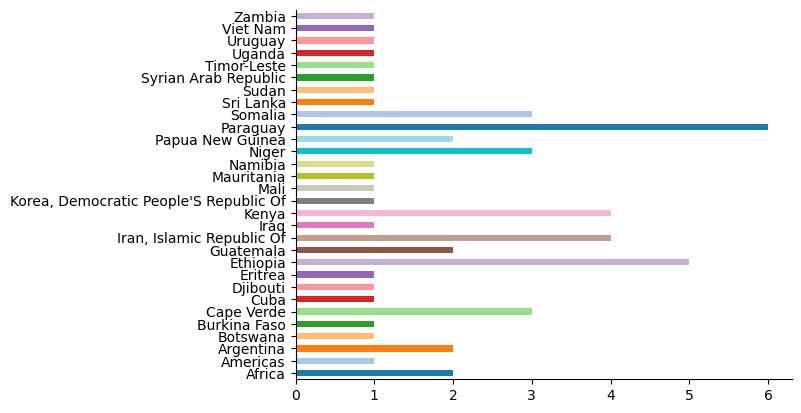

In [4]:
# Number of different locations covered by the reports

print(f'There are {len(data["location"].unique())} different locations covered by the reports')

grouped_data = data.groupby('location').size()
colors = sns.color_palette('tab20', n_colors=len(grouped_data))

# Plot the data
ax = grouped_data.plot(kind='barh', color=[colors[i] for i in range(len(grouped_data))])
ax.set_ylabel('')
ax.spines[['top', 'right']].set_visible(False)
plt.show()

### Text preparation

Before doing any analysis, we need to prepare the text. This will involve mainly:

- Cleaning the text: removing special characters, URLs, stopwords
- Tokenizing the text: breaking the text into smaller units, such as sentences

Keep in mind that text preprocessing is not limited to these tasks only. However, these should be enough for our purpose.

In [5]:
def clean_text(text, remove_numbers=False, remove_stopwords=False):
    # Remove hyperlinks
    text = re.sub(r'http\S+|www\S+', '', text)

    # Remove some special characters, leaving basic punctuation (e.g., commas, periods)
    text = re.sub(r'[^a-zA-Z0-9\s.,!?]', '', text)

    # Remove numbers if the option is enabled
    if remove_numbers:
        text = re.sub(r'\d+', '', text)

    # Remove newlines
    text = text.replace('\n', ' ')

    # Remove multiple spaces
    text = re.sub(r'\s+', ' ', text).strip()

    # Remove stopwords if the option is enabled
    if remove_stopwords:
        stop_words = set(stopwords.words('english'))
        text = ' '.join([word for word in text.split() if word.lower() not in stop_words])

    return text

In [6]:
data['text_preprocessed'] = data['text'].apply(clean_text)

In [7]:
nltk.download('punkt')  # Download sentence tokenizer
nltk.download('stopwords') # Download stopwords

[nltk_data] Downloading package punkt to /Users/lseverino/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/lseverino/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [8]:
import nltk
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt_tab to
[nltk_data]     /Users/lseverino/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [9]:
data['sentences'] = data['text_preprocessed'].apply(sent_tokenize)

In [10]:
data.columns

Index(['reportName', 'disasterType', 'date', 'reportLink', 'location',
       'appealCode', 'appealType', 'text', 'disasterTypeFlag',
       'text_preprocessed', 'sentences'],
      dtype='object')

Additional pre-processing steps could involve, for example:
- Removing the words less frequently mentioned
- Lemmatization: reducing words to their root form
- Stemmatization: reducing words to their [stem](https://en.wikipedia.org/wiki/Word_stem)

### Named entity recognition: extracting entities from text

In [11]:
# Load the English model for spaCy
nlp = spacy.load("en_core_web_sm")

In [12]:
def extract_entities(text):
    # Process the text with spaCy
    doc = nlp(text)
    entities = [(ent.text, ent.label_) for ent in doc.ents]
    return entities

data['entities'] = data['text_preprocessed'].apply(extract_entities)

In [ ]:
doc = nlp(data['text_preprocessed'][3][:1997])
displacy.render(doc, style="ent")

In [1]:
displacy.render(doc, style="ent")

NameError: name 'displacy' is not defined

### Identifying hazards mentioned in the text: keyword-based search

When trying to identify specific mentions of hazards in a text, one common approach is keyword-based search. In this method, we define a list of hazard-related keywords (such as "fire," "flood," "earthquake," etc.), and then check whether any of these keywords appear in the text. This is a straightforward method, but it has limitations: it may miss variations of the keywords (e.g., "flooding" vs. "flood") or detect false positives (where the keyword appears in a different context).


However, this limitation can be overcome using regular expressions (regex). Regex allows us to define patterns for more flexible searches. For instance, we can use regex to match different tenses of verbs (like "flood" and "flooding") or both singular and plural forms (like "landslide" and "landslides").

In [16]:
hazard_patterns = {
    r"\bfire(s)?\b": "fire",                         # matches 'fire' or 'fires'
    r"\bflood(ed|ing)?\b": "flood",                  # matches 'flood', 'flooded', 'flooding'
    r"\bheatwave(s)?\b": "heatwave",                 # matches 'heatwave', 'heatwaves'
    r"\bearthquake(s)?\b": "earthquake",             # matches 'earthquake' or 'earthquakes'
    r"\bhurricane(s)?\b": "hurricane",               # matches 'hurricane' or 'hurricanes'
    r"\blandslide(s)?\b": "landslide"                # matches 'landslide' or 'landslides'
}

In [17]:
# Function to search for hazard patterns in a text and return the corresponding hazard names
def identify_hazards_regex(text, patterns):
    found_hazards = []
    for pattern, hazard_name in patterns.items():
        if re.search(pattern, text.lower()):
            found_hazards.append(hazard_name)  # Append the hazard name instead of the matched text
    return found_hazards if found_hazards else None

# Apply the function to the 'text_preprocessed' column of the DataFrame
data['hazards_found'] = data['text_preprocessed'].apply(lambda x: identify_hazards_regex(x, hazard_patterns))

# Display results
print(data[['text_preprocessed', 'hazards_found']].head())

                                   text_preprocessed  hazards_found
0  DREF Operation BotswanaDrought The impact of d...  [fire, flood]
1  Page 1 21 DREF Operation Zambia Drought 2024 S...           None
2  Page 1 of 1 Cash contributions Inkind Goods Tr...           None
3  DREF APPLICATION Uruguay Droughts January 2023...         [fire]
4  P a g e 1 Internal DREF Operation MDRCV003 Gli...           None


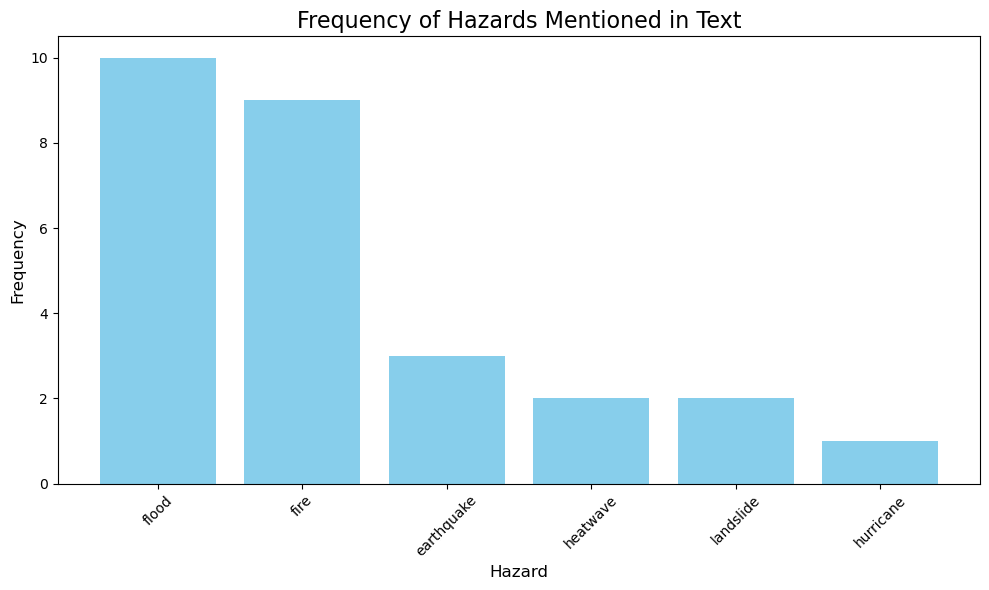

In [18]:
# Flatten the list of hazards and count the occurrences
hazard_counts = Counter([hazard for hazards_list in data['hazards_found'].dropna() for hazard in hazards_list])

# Convert the counter to a pandas DataFrame for easier plotting
hazard_df = pd.DataFrame(hazard_counts.items(), columns=['Hazard', 'Frequency'])

# Sort by frequency
hazard_df = hazard_df.sort_values(by='Frequency', ascending=False)

# Plot the data
plt.figure(figsize=(10,6))
plt.bar(hazard_df['Hazard'], hazard_df['Frequency'], color='skyblue')
plt.title('Frequency of Hazards Mentioned in Text', fontsize=16)
plt.xlabel('Hazard', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Let's see how expanding the regex patterns changes the results.



In [19]:
hazard_patterns = {
    r"\bfire(s)?|forestfire(s)?|wildfire(s)?|landfire(s)?|bushfire(s)?|forest fire(s)?|wild fire(s)?|land fire(s)?|bush fire(s)?\b": "fire",  # matches various forms of 'fire' and 'wildfire'
    r"\bflood(s)?|flooded|flooding|inundation(s)?|glacial lake outburst\b": "flood",  # matches 'flood', 'flooding', 'inundation', etc.
    r"\bstorm(s)?|superstorm(s)?|windstorm(s)?|snowstorm(s)?|snowfall(s)?|blizzard(s)?|derecho(s)?|winterstorm(s)?|hail(s)?|extra tropical storm(s)?|thunderstorm(s)?|storm surge(s)?|typhoon(s)?\b": "storm",  # matches various forms of storms
    r"\btornado(s)?\b": "tornado",  # matches 'tornado' or 'tornadoes'
    r"\bhurricane(s)?\b": "hurricane",  # matches 'hurricane' or 'hurricanes'
    r"\bheat wave(s)?|heatwave(s)?|heat episode(s)?|heat spell(s)?|hot spell(s)?|heat stress(es)?\b": "heatwave",  # matches 'heatwave', 'heat stress', etc.
    r"\bcold wave(s)?|coldwave(s)?|severe winter condition(s)?|cold spell(s)?\b": "coldwave",  # matches 'cold wave', 'cold spell', etc.
    r"\bland slide(s)?|landslide(s)?|rockfall(s)?|mudslide(s)?|mass movement(s)?\b": "mass movement",  # matches 'landslide', 'rockfall', etc.
    r"\bearthquake(s)?\b": "earthquake",  # matches 'earthquake' or 'earthquakes'
    r"\bcyclone(s)?|tropical cyclone(s)?\b": "cyclone",  # matches 'cyclone' or 'tropical cyclone'
}

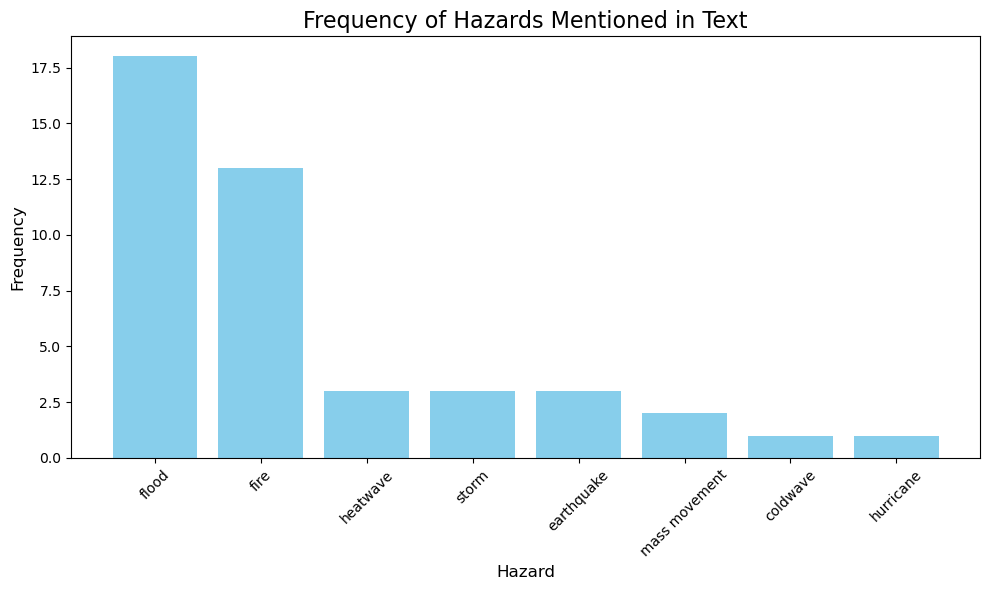

In [20]:
# Apply the function to the 'text_preprocessed' column of the DataFrame
data['hazards_found'] = data['text_preprocessed'].apply(lambda x: identify_hazards_regex(x, hazard_patterns))

# Flatten the list of hazards and count the occurrences
hazard_counts = Counter([hazard for hazards_list in data['hazards_found'].dropna() for hazard in hazards_list])

# Convert the counter to a pandas DataFrame for easier plotting
hazard_df = pd.DataFrame(hazard_counts.items(), columns=['Hazard', 'Frequency'])

# Sort by frequency
hazard_df = hazard_df.sort_values(by='Frequency', ascending=False)

# Plot the data
plt.figure(figsize=(10,6))
plt.bar(hazard_df['Hazard'], hazard_df['Frequency'], color='skyblue')
plt.title('Frequency of Hazards Mentioned in Text', fontsize=16)
plt.xlabel('Hazard', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

By expanding the regex patterns, we significantly enhance the flexibility and coverage of hazard detection. The original keyword-based approach was limited to exact matches, but with the new patterns, we can capture variations of hazard terms, such as plurals, verb conjugations, and alternative names.

A more advanced approach would be to train a Named Entity Recognition (NER) model. NER models are able to recognize and classify specific entities (like names of hazards) in a text. However, to train such a model, we would need labeled data, where each instance of a hazard is annotated in the text. Once trained, the NER model would generalize beyond simple keyword matches and identify hazards even when they appear in varied forms or synonyms.